In [1]:
from pathlib import Path
import gzip, pickle, warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import sncosmo
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table, vstack
from IPython.display import display

from matplotlib_venn import venn3

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA = ROOT / "data"

PANTHEON_HD = DATA / "pantheon/DataRelease/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES.dat"
PANTHEON_PHOT = DATA / "pantheon/DataRelease/Pantheon+_Data/1_DATA/photometry"
PANTHEON_SALT2 = DATA / "pantheon/DataRelease/Pantheon+_Data/3_SALT2/SALT2_B21trained_withsys/SALT2.MODEL000"
FILTER_ROOT = DATA / "pantheon/DataRelease/Pantheon+_Data/2_CALIBRATION/filters"

DES_META = DATA / "des/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_Metadata.csv"
DES_PHOT_PAIRS = [
    (DATA / "des/DES-SN5YR/0_DATA/DES-SN5YR_DES/DES-SN5YR_DES_HEAD.FITS",
     DATA / "des/DES-SN5YR/0_DATA/DES-SN5YR_DES/DES-SN5YR_DES_PHOT.FITS.gz"),
    (DATA / "des/DES-SN5YR/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz",
     DATA / "des/DES-SN5YR/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_PHOT.FITS.gz"),
    (DATA / "des/DES-SN5YR/0_DATA/DES-SN5YR_Foundation/DES-SN5YR_Foundation_HEAD.FITS.gz",
     DATA / "des/DES-SN5YR/0_DATA/DES-SN5YR_Foundation/DES-SN5YR_Foundation_PHOT.FITS.gz"),
]
DES_DOVEKIE = ROOT / "models/salt3-dovekie"

UNION3_PICKLE = DATA / "union3/union3_release/inputs_Amanullah10_CNIa02_CSP_CalanTololo_CfA1_CfA2_CfA3_CfA4_DES3_Deep_DES3_Shallow_ESSENCE_Foundation_LOSS_MCT_NB99_Pan-STARRS_Riess07_SDSS_SNLS_SuzukiRubin_Tonry03_LSQ+LCO_LSQ_knop03_Krisciunas.pickle"
UNION3_LCS = DATA / "union3/lcs"
UNION3_F22 = ROOT / "models/salt3-f22"

SNANA_MAG_OFFSET = 0.27
MWEBV_SCALE = 0.86
PHASE_RANGE = (-15.0, 45.0)
RESTLAMBDA = {"Pantheon+": (3000.0, 7000.0), "DES": (2800.0, 8000.0), "Union3": (2800.0, 8000.0)}
FIGDIR = ROOT / "figures/reproduce_release_fit_steps"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("sncosmo:", sncosmo.__version__)

ROOT: /home/abhi/tifr-project
sncosmo: 2.12.1


In [2]:
@dataclass
class CommonSN:
    cid: str
    des_cid: str
    u3_uid: str
    z: float


class ScaledSource(sncosmo.Source):
    def __init__(self, source, mag_offset):
        if isinstance(source, str):
            source = sncosmo.get_source(source)
        self._source = source
        self._scale = 10.0 ** (-0.4 * float(mag_offset))
        self.name = f"{getattr(source, 'name', 'source')}+magoffset"
        self.version = getattr(source, "version", None)
        self._param_names = list(source.param_names)
        self.param_names_latex = list(getattr(source, "param_names_latex", source.param_names))
        self._parameters = np.array(source.parameters, dtype=float)

    def minphase(self): return self._source.minphase()
    def maxphase(self): return self._source.maxphase()
    def minwave(self): return self._source.minwave()
    def maxwave(self): return self._source.maxwave()

    def _flux(self, phase, wave):
        self._source.parameters = self._parameters
        return self._scale * self._source._flux(phase, wave)


def band_available(name):
    try:
        sncosmo.get_bandpass(name)
        return True
    except Exception:
        return False


def read_two_column_bandpass(path, name):
    if band_available(name):
        return
    rows = []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        try:
            rows.append((float(parts[0]), float(parts[1])))
        except ValueError:
            pass
    if rows:
        arr = np.array(rows)
        sncosmo.register(sncosmo.Bandpass(arr[:, 0], arr[:, 1], name=name), name=name, force=True)


def register_release_bandpasses():
    specs = {
        "pplus_des_g": FILTER_ROOT / "DES-SN3YR_DECam/DECam_g.dat",
        "pplus_des_r": FILTER_ROOT / "DES-SN3YR_DECam/DECam_r.dat",
        "pplus_des_i": FILTER_ROOT / "DES-SN3YR_DECam/DECam_i.dat",
        "pplus_des_z": FILTER_ROOT / "DES-SN3YR_DECam/DECam_z.dat",
        "pplus_csp_u": FILTER_ROOT / "CSP_TAMU_20180316/u_tel_ccd_atm_ext_1.2.dat",
        "pplus_csp_b": FILTER_ROOT / "CSP_TAMU_20180316/B_tel_ccd_atm_ext_1.2.dat",
        "pplus_csp_g": FILTER_ROOT / "CSP_TAMU_20180316/g_tel_ccd_atm_ext_1.2.dat",
        "pplus_csp_r": FILTER_ROOT / "CSP_TAMU_20180316/r_tel_ccd_atm_ext_1.2.dat",
        "pplus_csp_i": FILTER_ROOT / "CSP_TAMU_20180316/i_tel_ccd_atm_ext_1.2.dat",
        "pplus_csp_y": FILTER_ROOT / "CSP_TAMU_20180316/Y_SWO_TAM_scan_atm.dat",
        "pplus_csp_j": FILTER_ROOT / "CSP_TAMU_20180316/Jrc2_SWO_TAM_scan_atm.dat",
        "pplus_csp_h": FILTER_ROOT / "CSP_TAMU_20180316/H_SWO_TAM_scan_atm.dat",
        "pplus_kep_u": FILTER_ROOT / "CFA3_native/keplercam_U.dat",
        "pplus_kep_b": FILTER_ROOT / "CFA3_native/keplercam_B.dat",
        "pplus_kep_v": FILTER_ROOT / "CFA3_native/keplercam_V.dat",
        "pplus_kep_r": FILTER_ROOT / "CFA3_native/keplercam_r.dat",
        "pplus_kep_i": FILTER_ROOT / "CFA3_native/keplercam_i.dat",
    }
    for name, path in specs.items():
        if path.exists():
            read_two_column_bandpass(path, name)

register_release_bandpasses()
print("Registered release bandpasses.")

Registered release bandpasses.


In [3]:
GENERIC_SNANA_BANDS = {
    "g": "desg", "r": "desr", "i": "desi", "z": "desz",
    "B": "bessellb", "V": "bessellv", "R": "bessellr", "I": "besselli",
    "b": "bessellb", "v": "bessellv",
    "CFA3K-U/p": "keplercam::us", "CFA3K-B/q": "keplercam::b", "CFA3K-V/r": "keplercam::v",
    "CFA3K-r/s": "keplercam::r", "CFA3K-i/t": "keplercam::i",
    "CSP-u/a": "cspu", "CSP-B/e": "cspb", "CSP-g/b": "cspg", "CSP-r/c": "cspr",
    "CSP-i/d": "cspi", "CSP-Y/j": "cspys", "CSP-J/l": "cspjs", "CSP-H/n": "csphs",
}

EXACT_SNANA_BANDS = {
    "g": "pplus_des_g", "r": "pplus_des_r", "i": "pplus_des_i", "z": "pplus_des_z",
    "B": "bessellb", "V": "bessellv", "R": "bessellr", "I": "besselli",
    "b": "bessellb", "v": "bessellv",
    "CFA3K-U/p": "pplus_kep_u", "CFA3K-B/q": "pplus_kep_b", "CFA3K-V/r": "pplus_kep_v",
    "CFA3K-r/s": "pplus_kep_r", "CFA3K-i/t": "pplus_kep_i",
    "CSP-u/a": "pplus_csp_u", "CSP-B/e": "pplus_csp_b", "CSP-g/b": "pplus_csp_g",
    "CSP-r/c": "pplus_csp_r", "CSP-i/d": "pplus_csp_i", "CSP-Y/j": "pplus_csp_y",
    "CSP-J/l": "pplus_csp_j", "CSP-H/n": "pplus_csp_h",
}

PANTHEON_GENERIC_BY_SURVEY = {
    "DES": {"g": "desg", "r": "desr", "i": "desi", "z": "desz"},
    "CSP": {"u": "cspu", "B": "cspb", "g": "cspg", "r": "cspr", "i": "cspi", "Y": "cspys", "y": "cspys", "J": "cspjs", "j": "cspjs", "H": "csphs", "h": "csphs"},
}

PANTHEON_EXACT_BY_SURVEY = {
    "DES": {"g": "pplus_des_g", "r": "pplus_des_r", "i": "pplus_des_i", "z": "pplus_des_z"},
    "CSP": {"u": "pplus_csp_u", "B": "pplus_csp_b", "g": "pplus_csp_g", "r": "pplus_csp_r", "i": "pplus_csp_i", "Y": "pplus_csp_y", "y": "pplus_csp_y", "J": "pplus_csp_j", "j": "pplus_csp_j", "H": "pplus_csp_h", "h": "pplus_csp_h"},
}

# Union3 CSP instrument-specific band → generic SNCosmo bandpass mapping
# (CfA3, CfA4, LOSS, SWOPE are instrument+filter combinations from the release)
UNION3_CSP_BANDS = {
    "SWOPE_u": "cspu", "SWOPE_g": "cspg", "SWOPE_r": "cspr", "SWOPE_i": "cspi",
    "SWOPE_B": "cspb", "SWOPE_V-LC-3014": "cspv3014",
    "CfA3_MC_B": "bessellb", "CfA3_MC_V": "bessellv",
    "CfA3_MC_r'": "sdssr", "CfA3_MC_i'": "sdssi",
    "CfA3_KC_B_1": "bessellb", "CfA3_KC_V_1": "bessellv",
    "CfA3_KC_r'_1": "sdssr", "CfA3_KC_i'_1": "sdssi",
    "CfA4_KC_B_1": "bessellb", "CfA4_KC_V_1": "bessellv",
    "CfA4_KC_r'_1": "sdssr", "CfA4_KC_i'_1": "sdssi",
    "CfA4_KC_B_2": "bessellb", "CfA4_KC_V_2": "bessellv",
    "CfA4_KC_r'_2": "sdssr", "CfA4_KC_i'_2": "sdssi",
    "LOSS_K3_B": "bessellb", "LOSS_K3_V": "bessellv",
    "LOSS_K3_R": "bessellr", "LOSS_K3_I": "besselli",
    "LOSS_K4_B": "bessellb", "LOSS_K4_V": "bessellv",
    "LOSS_K4_R": "bessellr", "LOSS_K4_I": "besselli",
    "LOSS_N1_B": "bessellb", "LOSS_N1_V": "bessellv",
    "LOSS_N1_R": "bessellr", "LOSS_N1_I": "besselli",
    "LOSS_N2_B": "bessellb", "LOSS_N2_V": "bessellv",
    "LOSS_N2_R": "bessellr", "LOSS_N2_I": "besselli",
    "Bessell12_R": "bessellr",
}
UNION3_DES_BANDS = {
    "DECam_g": "desg", "DECam_r": "desr", "DECam_i": "desi", "DECam_z": "desz",
    "DES_g": "desg", "DES_r": "desr", "DES_i": "desi", "DES_z": "desz",
}
UNION3_SDSS_BANDS = {
    "SDSS_g": "sdssg", "SDSS_r": "sdssr", "SDSS_i": "sdssi", "SDSS_z": "sdssz", "SDSS_u": "sdssu",
}
UNION3_BESSELL_BANDS = {
    "Bessell_B": "bessellb", "Bessell_V": "bessellv", "Bessell_R": "bessellr",
}

GENERIC_UNION3_BANDS = {
    **UNION3_DES_BANDS, **UNION3_CSP_BANDS, **UNION3_SDSS_BANDS, **UNION3_BESSELL_BANDS,
}

EXACT_UNION3_BANDS = {
    **GENERIC_UNION3_BANDS,
    "DECam_g": "pplus_des_g", "DECam_r": "pplus_des_r",
    "DECam_i": "pplus_des_i", "DECam_z": "pplus_des_z",
    "DES_g": "pplus_des_g", "DES_r": "pplus_des_r",
    "DES_i": "pplus_des_i", "DES_z": "pplus_des_z",
}

In [4]:
def read_des_metadata():
    cols = DES_META.read_text().splitlines()[0].replace("VARNAMES: ", "").split()
    df = pd.read_csv(DES_META, skiprows=1, names=cols, sep=r"\s+", skipinitialspace=True)
    df["CID"] = df["CID"].str.replace("SN:", "", regex=False).str.strip()
    return df.set_index("CID")


def read_union3_catalog():
    with gzip.open(UNION3_PICKLE, "rb") as f:
        sn_data, _metadata, _config = pickle.load(f)
    rows = []
    for i, path in enumerate(sn_data["snpaths"]):
        rel = path.split("Union3//", 1)[1]
        survey, sn_name = rel.split("/", 1)
        rows.append({
            "uid": sn_name, "survey": survey, "sn_name": sn_name, "rel": rel,
            "z": float(sn_data["z_CMB_list"][i]),
            "mB": float(sn_data["mB_list"][i]),
            "x1": float(sn_data["x1_list"][i]),
            "c": float(sn_data["c_list"][i]),
        })
    return pd.DataFrame(rows).set_index("uid")


def read_common_matches():
    with gzip.open(DATA / "analysis/hubble_data.pklz", "rb") as f:
        d = pickle.load(f)
    xd = d["xd"]
    pan_u3 = xd[xd["pair"] == "Pantheon+_vs_Union3"]
    des_pan = xd[xd["pair"] == "DES_vs_Pantheon+"]
    des_u3 = xd[xd["pair"] == "DES_vs_Union3"]
    out = []
    for row in des_pan.itertuples():
        cid, des_cid = str(row.uid_b), str(row.uid_a)
        pu = pan_u3[pan_u3["uid_a"].astype(str) == cid]
        du = des_u3[des_u3["uid_a"].astype(str) == des_cid]
        if len(pu) and len(du):
            out.append(CommonSN(cid=cid, des_cid=des_cid, u3_uid=str(pu.iloc[0]["uid_b"]), z=float(row.z)))
    return out


DES_META_DF = read_des_metadata()
UNION3_DF = read_union3_catalog()
MATCHES = read_common_matches()
print("Triple matches:", len(MATCHES))
display(pd.DataFrame([m.__dict__ for m in MATCHES[:10]]))

Triple matches: 333


,cid,des_cid,u3_uid,z
0,ASASSN-15pm,ASASSN-15pm,ASASSN-15pm,0.048370
1,1329312,1329312,01329312,0.344825
2,1341370,1341370,01341370,0.408975
3,1335717,1335717,01335717,0.304765
4,1338233,1338233,01338233,0.601515
5,2007co,2007co,SN2007co,0.027310
6,1299785,1299785,01299785,0.381300
7,1297465,1297465,01297465,0.277830
8,1258906,1258906,01258906,0.349150
9,1290816,1290816,01290816,0.218460


In [5]:
def find_match(cid=None, index=21):
    if cid is None:
        return MATCHES[index]
    cid = str(cid).strip().removeprefix("SN:")
    for m in MATCHES:
        if m.cid == cid or m.des_cid == cid or m.u3_uid.lstrip("0") == cid:
            return m
    raise ValueError(f"No triple match for {cid!r}")


def find_pantheon_photometry(match):
    tokens = {match.cid, match.des_cid, match.u3_uid, match.u3_uid.lstrip("0")}
    candidates = []
    for path in PANTHEON_PHOT.rglob("*"):
        if path.is_file() and path.suffix.lower() in {".dat", ".txt"}:
            stem = path.stem
            if any(stem == t or stem.endswith(f"_{t}") or stem.endswith(t) for t in tokens):
                candidates.append(path)
    if not candidates:
        raise FileNotFoundError(match)
    candidates.sort(key=lambda p: ("DES" not in str(p).upper(), len(str(p))))
    return candidates[0]


def snana_to_table(obs, band_map):
    rows = []
    band_col = "BAND" if "BAND" in obs.colnames else "FLT"
    for row in obs:
        band_key = str(row[band_col]).strip()
        band = band_map.get(band_key, band_key)
        if not band_available(band):
            continue
        rows.append({"time": float(row["MJD"]), "band": band, "flux": float(row["FLUXCAL"]), "fluxerr": float(row["FLUXCALERR"]), "zp": 27.5, "zpsys": "ab"})
    return Table(rows)


def load_pantheon_photometry(match, exact_bands):
    path = find_pantheon_photometry(match)
    meta, tables = sncosmo.read_snana_ascii(str(path), default_tablename="OBS")
    survey = str(meta.get("SURVEY", "")).upper()
    maps = PANTHEON_EXACT_BY_SURVEY if exact_bands else PANTHEON_GENERIC_BY_SURVEY
    band_map = maps.get(survey, EXACT_SNANA_BANDS if exact_bands else GENERIC_SNANA_BANDS)
    return snana_to_table(tables["OBS"], band_map), path


def load_des_photometry(match, exact_bands):
    band_map = EXACT_SNANA_BANDS if exact_bands else GENERIC_SNANA_BANDS
    for head_path, phot_path in DES_PHOT_PAIRS:
        with fits.open(head_path, memmap=True) as hdul:
            head = hdul[1].data
            idx = np.flatnonzero(np.char.strip(head["SNID"].astype(str)) == match.des_cid)
            if len(idx) != 1:
                continue
            hrow = head[int(idx[0])]
            j0, j1 = int(hrow["PTROBS_MIN"]) - 1, int(hrow["PTROBS_MAX"])
        with fits.open(phot_path, memmap=True) as hdul:
            return snana_to_table(Table(hdul[1].data[j0:j1]), band_map)
    raise FileNotFoundError(match.des_cid)


def load_union3_photometry(match, exact_bands):
    u3 = UNION3_DF.loc[match.u3_uid]
    lc_dir = UNION3_LCS / str(u3["survey"]) / str(u3["sn_name"])
    band_map = EXACT_UNION3_BANDS if exact_bands else GENERIC_UNION3_BANDS

    # Step 1: read all raw lc2fit data, preserving original format
    raw_obs = []  # list of dicts: time, band, mag/flux, err, zp, zpsys, is_mag
    has_nonab = False
    for path in sorted(lc_dir.glob("lc2fit_*.dat")):
        band_raw = None
        zpsys = "ab"
        for line in path.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            if line.startswith("@BAND"):
                band_raw = line.split(None, 1)[1].strip()
            elif line.startswith("@MAGSYS"):
                zpsys = line.split(None, 1)[1].strip().lower()
            elif line.startswith("#") or line.startswith("@"):
                continue
            elif band_raw is not None:
                parts = line.split()
                if len(parts) < 3:
                    continue
                snc_band = band_map.get(band_raw)
                if snc_band is None or not band_available(snc_band):
                    continue
                mjd = float(parts[0])
                v1, v2 = float(parts[1]), float(parts[2])
                if len(parts) >= 4:
                    # 4-col: flux, fluxerr, zp (DES / SDSS style)
                    if v1 > 0 and v2 > 0:
                        raw_obs.append(dict(time=mjd, band=snc_band,
                            flux=v1, fluxerr=v2, zp=float(parts[3]),
                            zpsys=zpsys, is_mag=False))
                else:
                    # 3-col: mag, magerr (CSP / CfA / LOSS style)
                    if 0 < v2 < 1:
                        raw_obs.append(dict(time=mjd, band=snc_band,
                            mag=v1, magerr=v2, zp=27.5,
                            zpsys=zpsys, is_mag=True))
                        if zpsys != "ab":
                            has_nonab = True

    if not raw_obs:
        return Table()

    # Step 2: if any data is in non-AB magsystem, compute per-band offsets
    # using result_salt2.dat published parameters and convert to AB fluxes
    if has_nonab:
        ZP_AB = 27.5
        result_path = lc_dir / "result_salt2.dat"
        offsets = compute_union3_offsets(match, raw_obs, result_path)

        rows = []
        for ob in raw_obs:
            if ob["is_mag"]:
                off = offsets.get(ob["band"], 0.0)
                ab_mag = ob["mag"] - off
                flux = 10.0 ** (0.4 * (ZP_AB - ab_mag))
                ferr = (2.5 / np.log(10)) * ob["magerr"] * flux
                rows.append({"time": ob["time"], "band": ob["band"],
                    "flux": flux, "fluxerr": ferr, "zp": ZP_AB, "zpsys": "ab"})
            else:
                rows.append({"time": ob["time"], "band": ob["band"],
                    "flux": ob["flux"], "fluxerr": ob["fluxerr"],
                    "zp": ob["zp"], "zpsys": ob["zpsys"]})
        return Table(rows)
    else:
        # All AB: convert mag-based obs to flux, pass 4-col through
        ZP_AB = 27.5
        rows = []
        for ob in raw_obs:
            if ob["is_mag"]:
                flux = 10.0 ** (0.4 * (ZP_AB - ob["mag"]))
                ferr = (2.5 / np.log(10)) * ob["magerr"] * flux
                rows.append({"time": ob["time"], "band": ob["band"],
                    "flux": flux, "fluxerr": ferr, "zp": ZP_AB, "zpsys": "ab"})
            else:
                rows.append({"time": ob["time"], "band": ob["band"],
                    "flux": ob["flux"], "fluxerr": ob["fluxerr"],
                    "zp": ob["zp"], "zpsys": ob["zpsys"]})
        return Table(rows)


def read_lightfile_param(path, key, default=None):
    if not Path(path).exists():
        return default
    for line in Path(path).read_text(errors="ignore").splitlines():
        parts = line.split()
        if parts and parts[0] == key and len(parts) > 1:
            try:
                return float(parts[1])
            except ValueError:
                return default
    return default


def compute_union3_offsets(match, raw_obs, result_path):
    # Compute per-band magsystem offsets using result_salt2.dat params.
    # Returns dict {band_name: offset_mag} where offset = mag_raw - mag_AB
    # for the published SALT3 model.  Positive offset means the raw system
    # is brighter than AB at that wavelength.
    if not result_path.exists():
        print(f"  [WARN] no result_salt2.dat for {match.u3_uid}, assuming AB")
        return {}

    # Read published params
    pub = {}
    for line in result_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if parts[0] == "DayMax":
            pub["t0"] = float(parts[1])
        elif parts[0] == "Redshift":
            pub["z"] = float(parts[1])
        elif parts[0] == "X0":
            pub["x0"] = float(parts[1])
        elif parts[0] == "X1":
            pub["x1"] = float(parts[1])
        elif parts[0] == "Color":
            pub["c"] = float(parts[1])

    if "x0" not in pub:
        print(f"  [WARN] incomplete result_salt2.dat for {match.u3_uid}, assuming AB")
        return {}

    # Build model with published params + MW extinction from lightfile
    mwebv = pub.get("mwebv", 0.0)
    sn_name = str(UNION3_DF.loc[match.u3_uid]["sn_name"])
    surv = str(UNION3_DF.loc[match.u3_uid]["survey"])
    lf = UNION3_LCS / surv / sn_name / "lightfile"
    mwebv = read_lightfile_param(lf, "MW_true_EBV", default=None)
    if mwebv is None:
        mwebv = read_lightfile_param(lf, "MWEBV", default=0.0)

    model = sncosmo.Model(source="salt3")
    if mwebv > 0:
        dust = sncosmo.CCM89Dust()
        model.add_effect(dust, "mw", "obs")
        model.set(mwebv=mwebv)
    model.set(z=pub["z"], t0=pub["t0"], x0=pub["x0"], x1=pub["x1"], c=pub["c"])

    # Compute per-band offsets
    offsets = {}
    bands_seen = set()
    for ob in raw_obs:
        if not ob["is_mag"] or ob["band"] in bands_seen:
            continue
        bands_seen.add(ob["band"])
        try:
            mm = model.bandmag(ob["band"], "ab", ob["time"])
            if np.isfinite(mm) and mm < 30:
                offsets[ob["band"]] = ob["mag"] - mm
        except Exception:
            pass

    n_found = len(offsets)
    n_total = len(bands_seen)
    if n_found < n_total:
        print(f"  [WARN] computed offsets for {n_found}/{n_total} bands for {match.u3_uid}")
    print(f"  Linear_AB11_off → AB offsets ({n_found} bands):")
    for b, o in sorted(offsets.items()):
        print(f"    {b:>15s}: {o:+.4f} mag")
    return offsets

In [6]:
def published_values(match):
    pan = pd.read_csv(PANTHEON_HD, sep=r"\s+")
    pan_row = pan[pan["CID"].astype(str) == match.cid].iloc[0]
    pan_pub = {"z": float(pan_row["zHD"]), "t0": float(pan_row["PKMJD"]), "x0": float(pan_row["x0"]), "x1": float(pan_row["x1"]), "c": float(pan_row["c"]), "mB": float(pan_row["mB"]), "mwebv": float(pan_row["MWEBV"])}

    des_row = DES_META_DF.loc[match.des_cid]
    des_pub = {"z": float(des_row["zHD"]), "t0": float(des_row["PKMJD"]), "x0": float(des_row["x0"]), "x1": float(des_row["x1"]), "c": float(des_row["c"]), "mB": float(des_row["mB"]), "mwebv": float(des_row["MWEBV"])}

    u3 = UNION3_DF.loc[match.u3_uid]
    result = UNION3_LCS / str(u3["survey"]) / str(u3["sn_name"]) / "result_salt2.dat"
    lightfile = UNION3_LCS / str(u3["survey"]) / str(u3["sn_name"]) / "lightfile"
    u3_pub = {"z": float(u3["z"]), "mB": float(u3["mB"]), "x1": float(u3["x1"]), "c": float(u3["c"]), "mwebv": read_lightfile_param(lightfile, "MW_true_EBV", default=None)}
    if u3_pub["mwebv"] is None:
        u3_pub["mwebv"] = read_lightfile_param(lightfile, "MWEBV", default=0.0)
    for line in result.read_text().splitlines():
        if line.startswith("DayMax"):
            u3_pub["t0"] = float(line.split()[1])
        elif line.startswith("X0"):
            u3_pub["x0"] = float(line.split()[1])
    return {"Pantheon+": pan_pub, "DES": des_pub, "Union3": u3_pub}

In [7]:
def make_source(dataset, mag_offset):
    if dataset == "Pantheon+":
        source = "salt2"
        if (PANTHEON_SALT2 / "salt2_template_0.dat").exists():
            source = sncosmo.models.SALT2Source(modeldir=str(PANTHEON_SALT2))
        return ScaledSource(source, SNANA_MAG_OFFSET) if mag_offset else source
    if dataset == "DES":
        source = sncosmo.models.SALT3Source(modeldir=str(DES_DOVEKIE))
        return ScaledSource(source, SNANA_MAG_OFFSET) if mag_offset else source
    if dataset == "Union3":
        return sncosmo.models.SALT3Source(modeldir=str(UNION3_F22)) if UNION3_F22.exists() else "salt3"
    raise ValueError(dataset)


def filter_fit_data(data, pub, dataset, apply_cuts):
    if not apply_cuts:
        return data[np.asarray(data["fluxerr"], dtype=float) > 0]
    z, t0 = pub["z"], pub["t0"]
    phase = (np.asarray(data["time"], dtype=float) - t0) / (1.0 + z)
    keep = (phase >= PHASE_RANGE[0]) & (phase <= PHASE_RANGE[1])
    lam_min, lam_max = RESTLAMBDA[dataset]
    for i, band_name in enumerate(data["band"]):
        try:
            band = sncosmo.get_bandpass(str(band_name))
            rest_effwave = band.wave_eff / (1.0 + z)
            keep[i] &= lam_min <= rest_effwave <= lam_max
        except Exception:
            keep[i] = False
    keep &= np.asarray(data["fluxerr"], dtype=float) > 0
    return data[keep]


def fit_lightcurve(data, dataset, pub, step):
    source = make_source(dataset, step["mag_offset"])
    if step["mw_extinction"]:
        model = sncosmo.Model(source=source, effects=[sncosmo.F99Dust(r_v=3.1)], effect_names=["mw"], effect_frames=["obs"])
        model.set(mwebv=MWEBV_SCALE * float(pub.get("mwebv", 0.0) or 0.0))
    else:
        model = sncosmo.Model(source=source)
    model.set(z=pub["z"], t0=pub["t0"])
    bounds = {"t0": (pub["t0"] - 20, pub["t0"] + 20), "x0": (1e-12, 1.0), "x1": (-5.0, 5.0), "c": (-0.5, 0.5)}
    res, fitted = sncosmo.fit_lc(data, model, ["t0", "x0", "x1", "c"], bounds=bounds, guess_amplitude=True, guess_t0=False, minsnr=0.0, verbose=False)
    return {"t0": float(fitted.get("t0")), "x0": float(fitted.get("x0")), "x1": float(fitted.get("x1")), "c": float(fitted.get("c")), "chisq": float(res.chisq), "ndof": int(res.ndof), "nfit": len(data)}


STEPS = [
    {"name": "01_direct_generic", "exact_bands": False, "mag_offset": False, "cuts": False, "mw_extinction": False},
    {"name": "02_mag_offset", "exact_bands": False, "mag_offset": True, "cuts": False, "mw_extinction": False},
    {"name": "03_exact_bands", "exact_bands": True, "mag_offset": True, "cuts": False, "mw_extinction": False},
    {"name": "04_phase_lambda_cuts", "exact_bands": True, "mag_offset": True, "cuts": True, "mw_extinction": False},
    {"name": "05_mw_extinction", "exact_bands": True, "mag_offset": True, "cuts": True, "mw_extinction": True},
]

In [8]:
TARGET_CID = "1334084"  # Change this to e.g. "2005hc"
MATCH = find_match(TARGET_CID)
PUB = published_values(MATCH)

print(MATCH)
display(pd.DataFrame(PUB).T)

CommonSN(cid='1334084', des_cid='1334084', u3_uid='01334084', z=0.133575)


,z,t0,x0,x1,c,mB,mwebv
Pantheon+,0.133660,57336.300000,0.000177,-0.905296,0.071312,20.014200,0.033915
DES,0.133490,57336.445300,0.000175,-0.913942,0.088681,20.027140,0.033915
Union3,0.133478,57336.436777,0.000137,-0.653273,0.096607,20.304515,0.034000


In [9]:
def load_all_photometry(match, exact_bands):
    pan, pan_path = load_pantheon_photometry(match, exact_bands)
    return {
        "Pantheon+": pan,
        "DES": load_des_photometry(match, exact_bands),
        "Union3": load_union3_photometry(match, exact_bands),
    }, pan_path


all_results = []
loaded_by_exact = {}
for exact in [False, True]:
    loaded_by_exact[exact], pan_path = load_all_photometry(MATCH, exact)

print("Pantheon+ file:", pan_path.relative_to(ROOT))
for step in STEPS:
    phot = loaded_by_exact[step["exact_bands"]]
    for dataset in ["Pantheon+", "DES", "Union3"]:
        data = filter_fit_data(phot[dataset], PUB[dataset], dataset, step["cuts"])
        try:
            fit = fit_lightcurve(data, dataset, PUB[dataset], step)
            row = {"step": step["name"], "dataset": dataset, "nraw": len(phot[dataset]), **fit}
            for p in ["t0", "x0", "x1", "c", "mB"]:
                row[f"pub_{p}"] = PUB[dataset].get(p, np.nan)
            row["dt0"] = row["t0"] - row["pub_t0"]
            row["dx0_frac"] = row["x0"] / row["pub_x0"] - 1
            row["dmB_from_x0"] = -2.5 * np.log10(row["x0"] / row["pub_x0"])
            row["dx1"] = row["x1"] - row["pub_x1"]
            row["dc"] = row["c"] - row["pub_c"]
        except Exception as exc:
            row = {"step": step["name"], "dataset": dataset, "nraw": len(phot[dataset]), "error": repr(exc)}
        all_results.append(row)

results = pd.DataFrame(all_results)
display(results)

Pantheon+ file: data/pantheon/DataRelease/Pantheon+_Data/1_DATA/photometry/DES3YR_DES_COMBINED_TEXT/des_real_01334084.dat


,step,dataset,nraw,t0,x0,x1,c,chisq,ndof,nfit,pub_t0,pub_x0,pub_x1,pub_c,pub_mB,dt0,dx0_frac,dmB_from_x0,dx1,dc
0,01_direct_generic,Pantheon+,68,57336.632495,0.000121,-0.822348,0.127541,468.991969,64,68,57336.300000,0.000177,-0.905296,0.071312,20.014200,0.332495,-0.318189,0.415840,0.082948,0.056229
1,01_direct_generic,DES,96,57336.524389,0.000124,-0.953984,0.105895,367.959008,92,96,57336.445300,0.000175,-0.913942,0.088681,20.027140,0.079089,-0.290636,0.372828,-0.040042,0.017214
2,01_direct_generic,Union3,32,57336.577817,0.000123,-0.778008,0.124111,36.902362,28,32,57336.436777,0.000137,-0.653273,0.096607,20.304515,0.141040,-0.100434,0.114918,-0.124735,0.027503
3,02_mag_offset,Pantheon+,68,57336.632495,0.000155,-0.822348,0.127541,468.991969,64,68,57336.300000,0.000177,-0.905296,0.071312,20.014200,0.332495,-0.125693,0.145840,0.082948,0.056229
4,02_mag_offset,DES,96,57336.524389,0.000159,-0.953984,0.105895,367.959008,92,96,57336.445300,0.000175,-0.913942,0.088681,20.027140,0.079089,-0.090361,0.102828,-0.040042,0.017214
5,02_mag_offset,Union3,32,57336.577817,0.000123,-0.778008,0.124111,36.902362,28,32,57336.436777,0.000137,-0.653273,0.096607,20.304515,0.141040,-0.100434,0.114918,-0.124735,0.027503
6,03_exact_bands,Pantheon+,68,57336.633631,0.000155,-0.820751,0.128061,468.857848,64,68,57336.300000,0.000177,-0.905296,0.071312,20.014200,0.333631,-0.126203,0.146474,0.084545,0.056749
7,03_exact_bands,DES,96,57336.524097,0.000159,-0.955961,0.105862,368.425675,92,96,57336.445300,0.000175,-0.913942,0.088681,20.027140,0.078797,-0.090320,0.102778,-0.042019,0.017182
8,03_exact_bands,Union3,32,57336.578948,0.000123,-0.775976,0.124474,36.945363,28,32,57336.436777,0.000137,-0.653273,0.096607,20.304515,0.142171,-0.100882,0.115458,-0.122703,0.027866
9,04_phase_lambda_cuts,Pantheon+,68,57336.560285,0.000152,-0.779945,0.155565,22.543721,11,15,57336.300000,0.000177,-0.905296,0.071312,20.014200,0.260285,-0.140512,0.164400,0.125351,0.084253


## Fit vs Published Summary

In [10]:
summary_cols = ["step", "dataset", "nraw", "nfit", "chisq", "ndof", "dt0", "dx0_frac", "dmB_from_x0", "dx1", "dc"]
display(results[summary_cols].style.format({
    "chisq": "{:.2f}", "dt0": "{:+.3f}", "dx0_frac": "{:+.4f}",
    "dmB_from_x0": "{:+.4f}", "dx1": "{:+.4f}", "dc": "{:+.4f}"
}))

,step,dataset,nraw,nfit,chisq,ndof,dt0,dx0_frac,dmB_from_x0,dx1,dc
0,01_direct_generic,Pantheon+,68,68,468.99,64,+0.332,-0.3182,+0.4158,+0.0829,+0.0562
1,01_direct_generic,DES,96,96,367.96,92,+0.079,-0.2906,+0.3728,-0.0400,+0.0172
2,01_direct_generic,Union3,32,32,36.90,28,+0.141,-0.1004,+0.1149,-0.1247,+0.0275
3,02_mag_offset,Pantheon+,68,68,468.99,64,+0.332,-0.1257,+0.1458,+0.0829,+0.0562
4,02_mag_offset,DES,96,96,367.96,92,+0.079,-0.0904,+0.1028,-0.0400,+0.0172
5,02_mag_offset,Union3,32,32,36.90,28,+0.141,-0.1004,+0.1149,-0.1247,+0.0275
6,03_exact_bands,Pantheon+,68,68,468.86,64,+0.334,-0.1262,+0.1465,+0.0845,+0.0567
7,03_exact_bands,DES,96,96,368.43,92,+0.079,-0.0903,+0.1028,-0.0420,+0.0172
8,03_exact_bands,Union3,32,32,36.95,28,+0.142,-0.1009,+0.1155,-0.1227,+0.0279
9,04_phase_lambda_cuts,Pantheon+,68,15,22.54,11,+0.260,-0.1405,+0.1644,+0.1254,+0.0843


## Step-by-Step Residual Plots

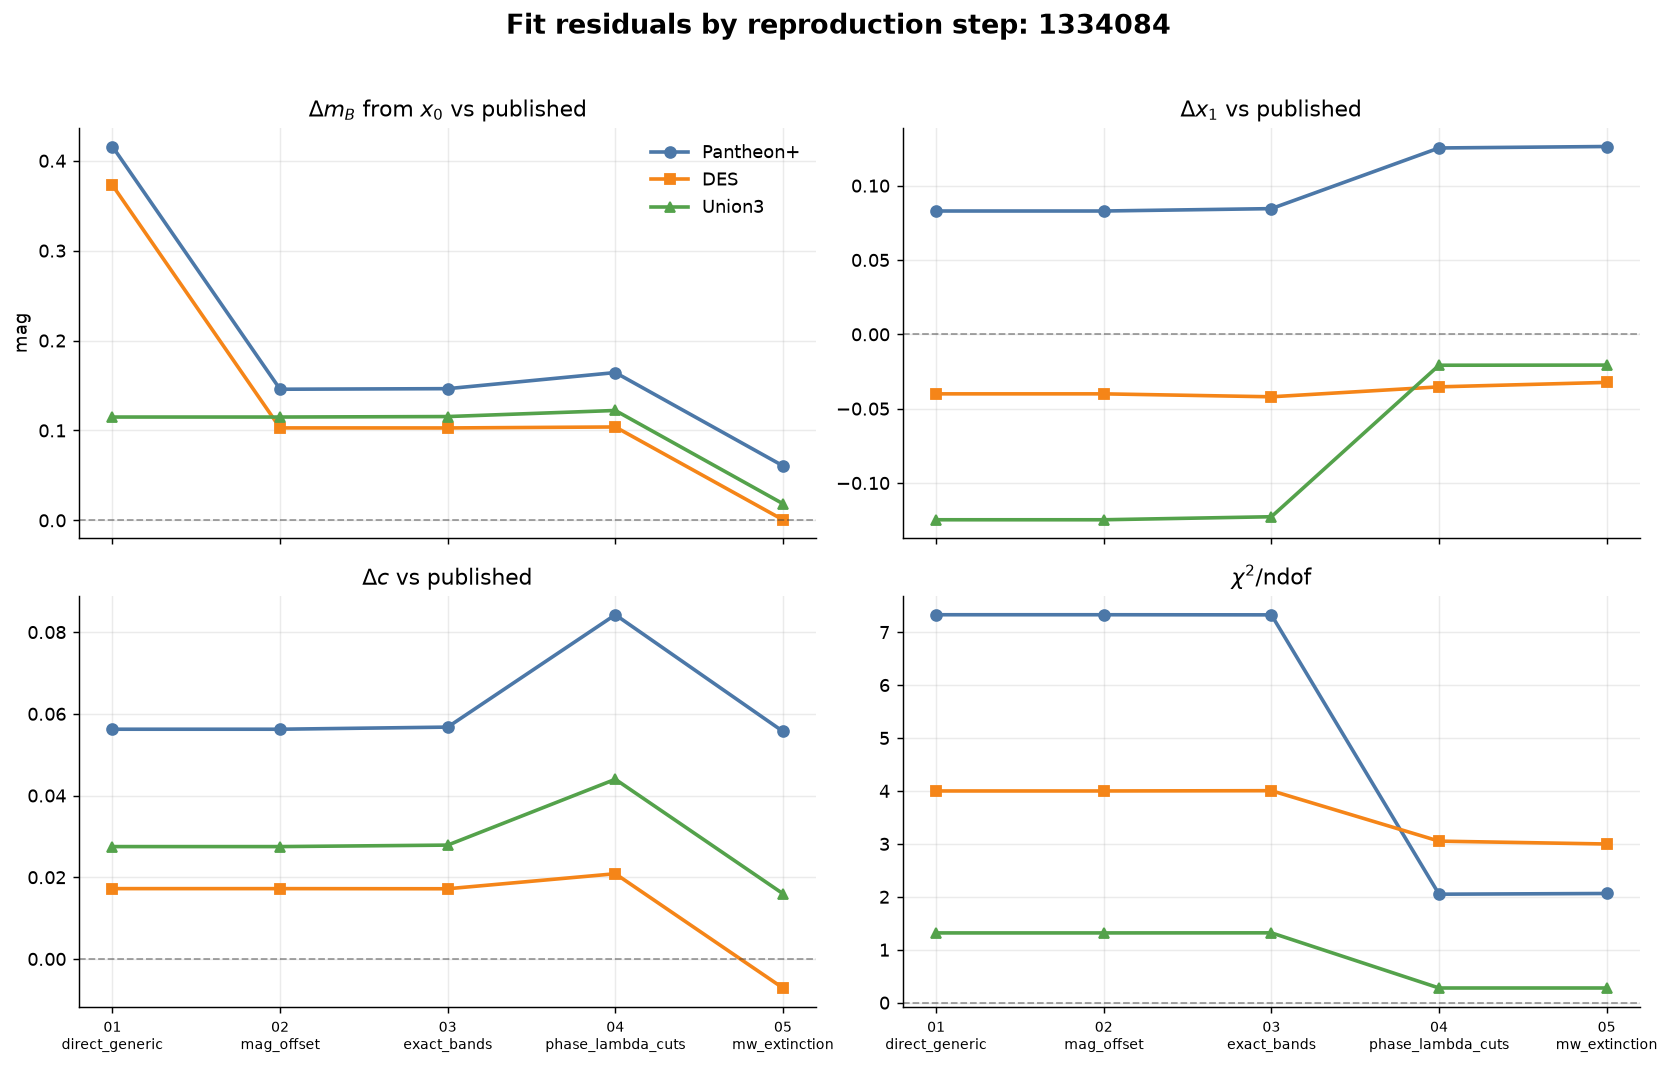

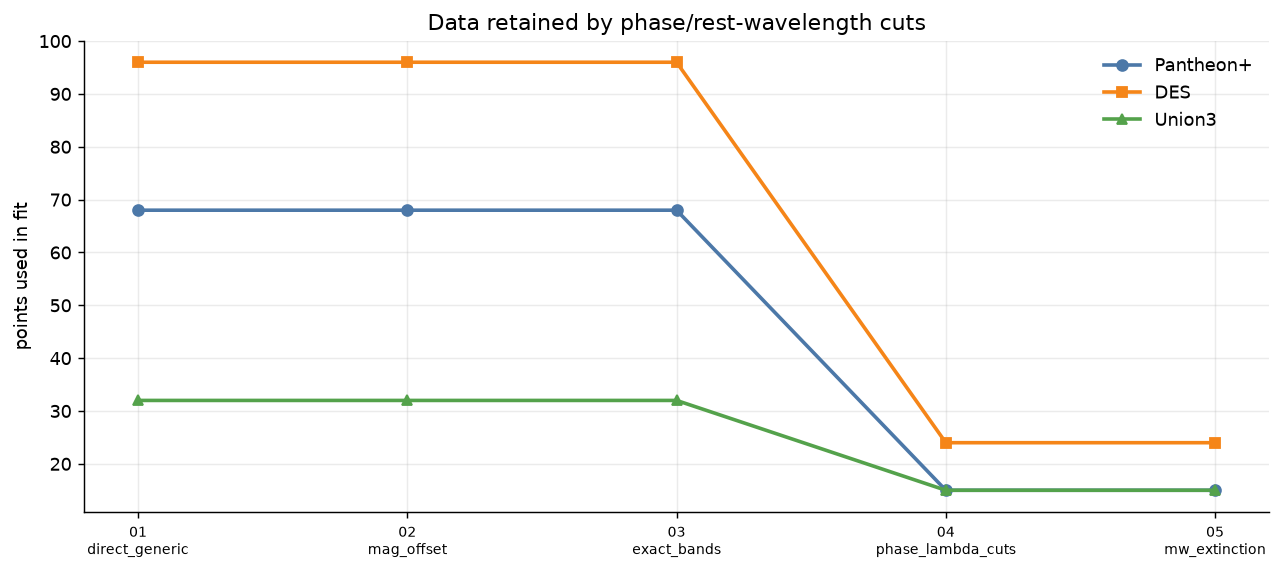

In [11]:
plot_df = results.dropna(subset=["x0"]).copy()
plot_df["step_index"] = plot_df["step"].map({s["name"]: i for i, s in enumerate(STEPS)})
plot_df["chi2_ndof"] = plot_df["chisq"] / plot_df["ndof"]
colors = {"Pantheon+": "#4C78A8", "DES": "#F58518", "Union3": "#54A24B"}
markers = {"Pantheon+": "o", "DES": "s", "Union3": "^"}
step_labels = [s["name"].replace("_", "\n", 1) for s in STEPS]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
panels = [
    ("dmB_from_x0", r"$\Delta m_B$ from $x_0$ vs published", "mag"),
    ("dx1", r"$\Delta x_1$ vs published", ""),
    ("dc", r"$\Delta c$ vs published", ""),
    ("chi2_ndof", r"$\chi^2/\mathrm{ndof}$", ""),
]

for ax, (col, title, ylabel) in zip(axes.ravel(), panels):
    for dataset, grp in plot_df.groupby("dataset", sort=False):
        grp = grp.sort_values("step_index")
        ax.plot(grp["step_index"], grp[col], marker=markers[dataset], color=colors[dataset], lw=2, label=dataset)
    ax.axhline(0, color="0.25", lw=1, ls="--", alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(STEPS)))
    ax.set_xticklabels(step_labels, rotation=0, fontsize=8)
axes[0, 0].legend(frameon=False)
fig.suptitle(f"Fit residuals by reproduction step: {MATCH.cid}", fontsize=15, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR / f"{MATCH.cid}_step_residuals.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
for dataset, grp in plot_df.groupby("dataset", sort=False):
    grp = grp.sort_values("step_index")
    ax.plot(grp["step_index"], grp["nfit"], marker=markers[dataset], color=colors[dataset], lw=2, label=dataset)
ax.set_xticks(range(len(STEPS)))
ax.set_xticklabels(step_labels, fontsize=8)
ax.set_ylabel("points used in fit")
ax.set_title("Data retained by phase/rest-wavelength cuts")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / f"{MATCH.cid}_nfit_by_step.png", bbox_inches="tight")
plt.show()

## Pairwise Dataset Comparisons at Each Step

In [12]:
def pairwise_table(df, use_published=False):
    rows = []
    pairs = [("Pantheon+", "DES"), ("Pantheon+", "Union3"), ("DES", "Union3")]
    if use_published:
        source = {k: {"x0": v["x0"], "x1": v["x1"], "c": v["c"], "mB": v["mB"]} for k, v in PUB.items()}
        for a, b in pairs:
            rows.append({"step": "published", "pair": f"{a} - {b}", "dmB": source[a]["mB"] - source[b]["mB"], "x0_ratio_a_over_b": source[a]["x0"] / source[b]["x0"], "dx1": source[a]["x1"] - source[b]["x1"], "dc": source[a]["c"] - source[b]["c"]})
        return pd.DataFrame(rows)

    for step, grp in df.groupby("step", sort=False):
        by = {r["dataset"]: r for _, r in grp.iterrows() if pd.isna(r.get("error", np.nan))}
        for a, b in pairs:
            if a not in by or b not in by:
                continue
            ra, rb = by[a], by[b]
            rows.append({"step": step, "pair": f"{a} - {b}", "dmB_from_x0": -2.5 * np.log10(ra["x0"] / rb["x0"]), "x0_ratio_a_over_b": ra["x0"] / rb["x0"], "dx1": ra["x1"] - rb["x1"], "dc": ra["c"] - rb["c"]})
    return pd.DataFrame(rows)

published_pairs = pairwise_table(results, use_published=True)
fit_pairs = pairwise_table(results)
display(published_pairs)
display(fit_pairs.style.format({"dmB_from_x0": "{:+.4f}", "x0_ratio_a_over_b": "{:.4f}", "dx1": "{:+.4f}", "dc": "{:+.4f}"}))

,step,pair,dmB,x0_ratio_a_over_b,dx1,dc
0,published,Pantheon+ - DES,-0.012940,1.011951,0.008646,-0.017369
1,published,Pantheon+ - Union3,-0.290315,1.297093,-0.252023,-0.025295
2,published,DES - Union3,-0.277375,1.281774,-0.260669,-0.007927


,step,pair,dmB_from_x0,x0_ratio_a_over_b,dx1,dc
0,01_direct_generic,Pantheon+ - DES,+0.0301,0.9726,+0.1316,+0.0216
1,01_direct_generic,Pantheon+ - Union3,+0.0185,0.9831,-0.0443,+0.0034
2,01_direct_generic,DES - Union3,-0.0116,1.0108,-0.1760,-0.0182
3,02_mag_offset,Pantheon+ - DES,+0.0301,0.9726,+0.1316,+0.0216
4,02_mag_offset,Pantheon+ - Union3,-0.2515,1.2607,-0.0443,+0.0034
5,02_mag_offset,DES - Union3,-0.2816,1.2961,-0.1760,-0.0182
6,03_exact_bands,Pantheon+ - DES,+0.0308,0.9720,+0.1352,+0.0222
7,03_exact_bands,Pantheon+ - Union3,-0.2514,1.2606,-0.0448,+0.0036
8,03_exact_bands,DES - Union3,-0.2822,1.2968,-0.1800,-0.0186
9,04_phase_lambda_cuts,Pantheon+ - DES,+0.0476,0.9571,+0.1693,+0.0460


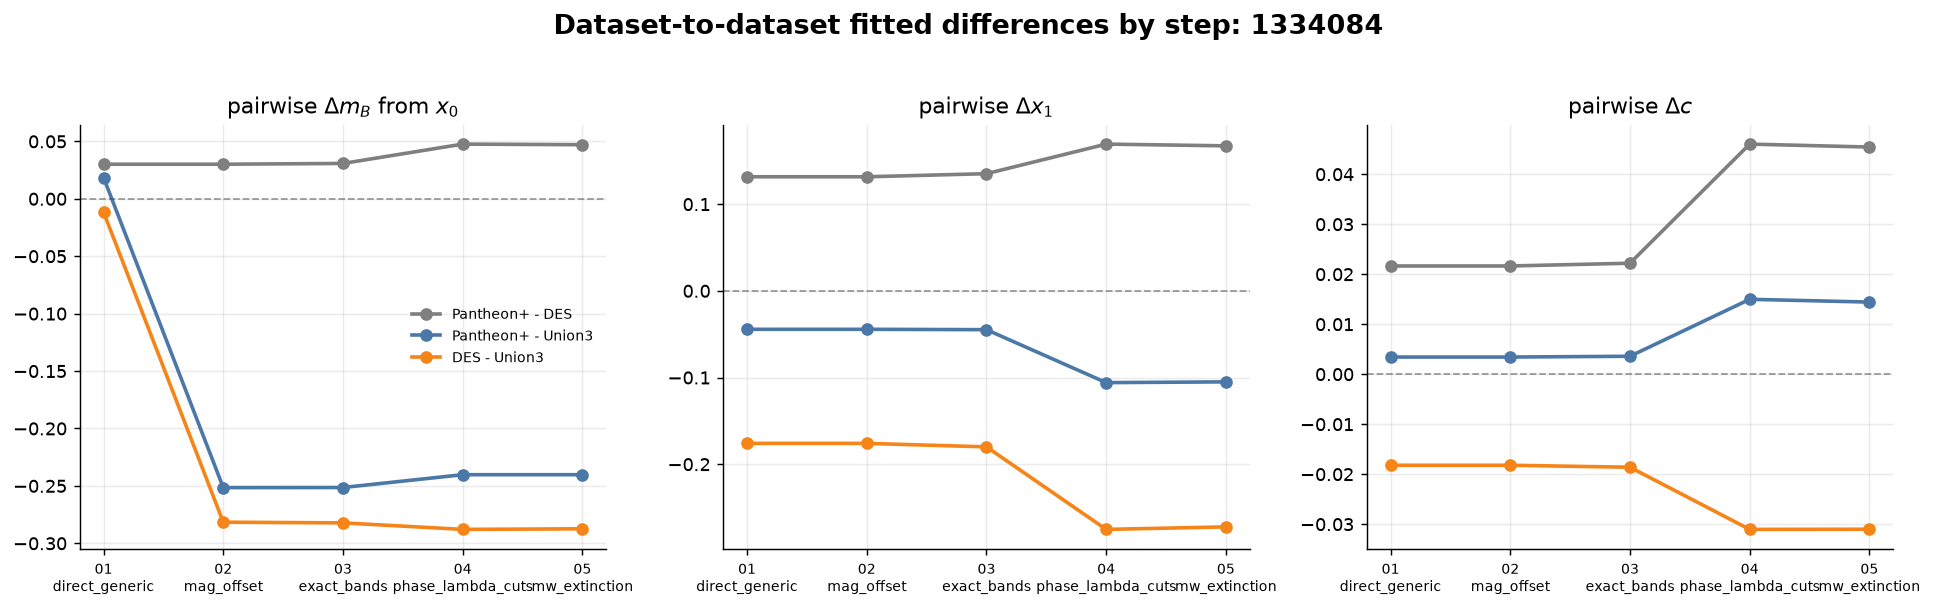

In [13]:
pair_plot = fit_pairs.copy()
pair_plot["step_index"] = pair_plot["step"].map({s["name"]: i for i, s in enumerate(STEPS)})
pair_colors = {"Pantheon+ - DES": "#7F7F7F", "Pantheon+ - Union3": "#4C78A8", "DES - Union3": "#F58518"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
for ax, col, ylabel in zip(
    axes,
    ["dmB_from_x0", "dx1", "dc"],
    [r"pairwise $\Delta m_B$ from $x_0$", r"pairwise $\Delta x_1$", r"pairwise $\Delta c$"],
):
    for pair, grp in pair_plot.groupby("pair", sort=False):
        grp = grp.sort_values("step_index")
        ax.plot(grp["step_index"], grp[col], marker="o", lw=2, color=pair_colors.get(pair), label=pair)
    ax.axhline(0, color="0.25", lw=1, ls="--", alpha=0.5)
    ax.set_title(ylabel)
    ax.set_xticks(range(len(STEPS)))
    ax.set_xticklabels(step_labels, rotation=0, fontsize=8)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Dataset-to-dataset fitted differences by step: {MATCH.cid}", fontsize=15, weight="bold", y=1.03)
fig.tight_layout()
fig.savefig(FIGDIR / f"{MATCH.cid}_pairwise_by_step.png", bbox_inches="tight")
plt.show()

## Final-Step Fitted vs Published Parameters

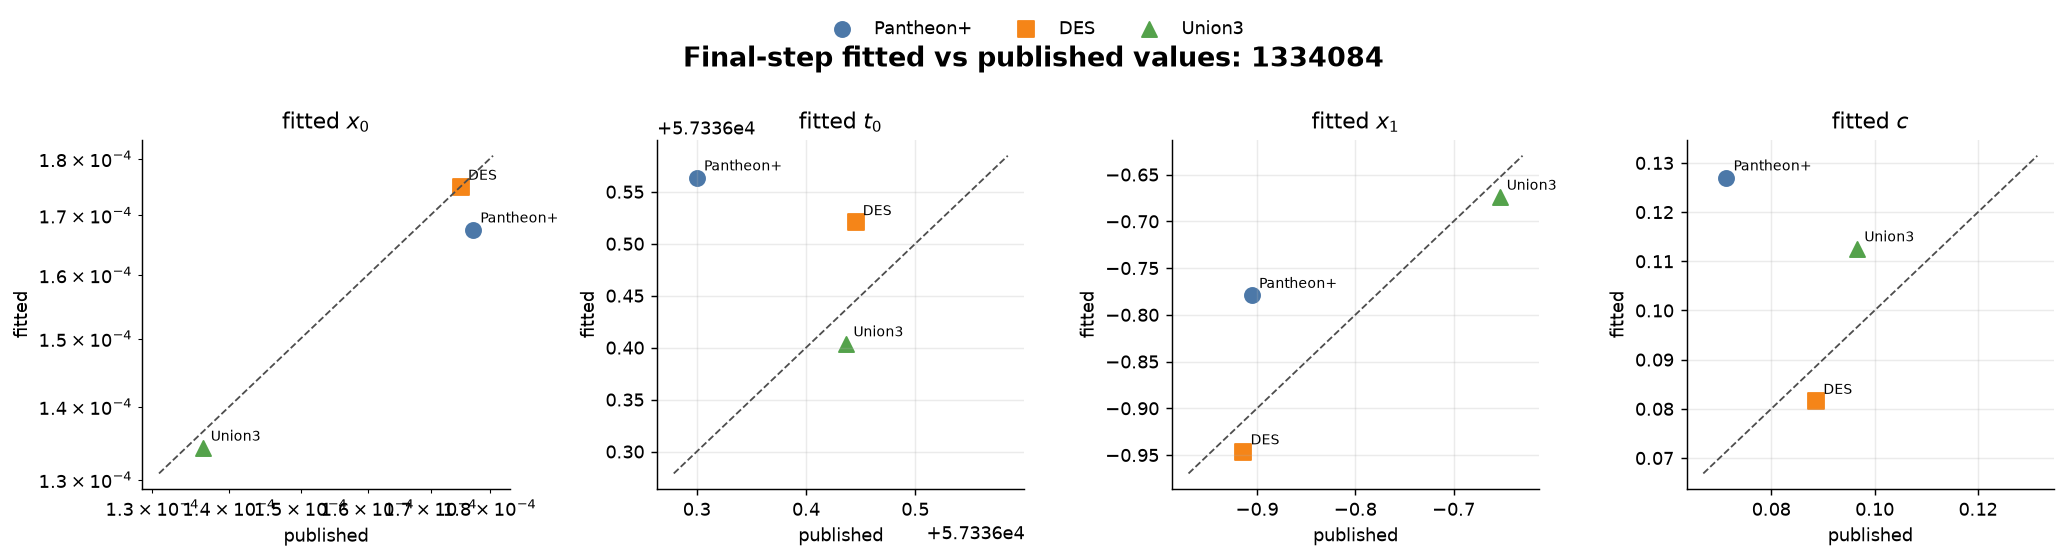

In [14]:
final_step = STEPS[-1]["name"]
final = results[results["step"] == final_step].dropna(subset=["x0"]).copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
param_info = [
    ("x0", "pub_x0", "fitted $x_0$", True),
    ("t0", "pub_t0", "fitted $t_0$", False),
    ("x1", "pub_x1", "fitted $x_1$", False),
    ("c", "pub_c", "fitted $c$", False),
]
for ax, (fit_col, pub_col, title, logscale) in zip(axes, param_info):
    vals = []
    for _, row in final.iterrows():
        ax.scatter(row[pub_col], row[fit_col], s=70, marker=markers[row["dataset"]], color=colors[row["dataset"]], label=row["dataset"])
        vals.extend([row[pub_col], row[fit_col]])
        ax.annotate(row["dataset"], (row[pub_col], row[fit_col]), xytext=(4, 4), textcoords="offset points", fontsize=8)
    vals = np.array(vals, dtype=float)
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    pad = 0.08 * (hi - lo if hi > lo else abs(hi) + 1)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="0.3", ls="--", lw=1)
    ax.set_xlabel("published")
    ax.set_ylabel("fitted")
    ax.set_title(title)
    if logscale:
        ax.set_xscale("log")
        ax.set_yscale("log")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.suptitle(f"Final-step fitted vs published values: {MATCH.cid}", fontsize=15, weight="bold", y=1.0)
fig.tight_layout()
fig.savefig(FIGDIR / f"{MATCH.cid}_final_fit_vs_published.png", bbox_inches="tight")
plt.show()

## Multi-SN Summary across All Triple Matches

In [15]:
def run_target(cid):
    match = find_match(cid)
    pub = published_values(match)
    rows = []
    cache = {}
    for exact in [False, True]:
        cache[exact], _ = load_all_photometry(match, exact)
    for step in STEPS:
        phot = cache[step["exact_bands"]]
        for dataset in ["Pantheon+", "DES", "Union3"]:
            data = filter_fit_data(phot[dataset], pub[dataset], dataset, step["cuts"])
            try:
                fit = fit_lightcurve(data, dataset, pub[dataset], step)
                rows.append({"cid": cid, "step": step["name"], "dataset": dataset, "nfit": len(data), "dmB_from_x0": -2.5*np.log10(fit["x0"]/pub[dataset]["x0"]), "dx1": fit["x1"]-pub[dataset]["x1"], "dc": fit["c"]-pub[dataset]["c"], "chisq_ndof": fit["chisq"]/fit["ndof"] if fit["ndof"] else np.nan})
            except Exception as exc:
                rows.append({"cid": cid, "step": step["name"], "dataset": dataset, "error": repr(exc)})
    return pd.DataFrame(rows)


def run_all_matches(max_sne=50):
    """Run last-step fit on up to max_sne triple matches and return summary."""
    final_step = STEPS[-1]["name"]
    all_rows = []
    n_ok = 0
    for i, match in enumerate(MATCHES):
        if n_ok >= max_sne:
            break
        if i % 10 == 0:
            print(f"  progress: {i}/{len(MATCHES)} checked, {n_ok} done...")
        try:
            pub = published_values(match)
            cache = {}
            for exact in [False, True]:
                cache[exact], _ = load_all_photometry(match, exact)
            for dataset in ["Pantheon+", "DES", "Union3"]:
                phot = cache[STEPS[-1]["exact_bands"]]
                data = filter_fit_data(phot[dataset], pub[dataset], dataset, final_step)
                fit = fit_lightcurve(data, dataset, pub[dataset], STEPS[-1])
                all_rows.append({"cid": str(match.cid), "des_cid": match.des_cid,
                    "u3_uid": match.u3_uid, "z": match.z,
                    "dataset": dataset,
                    "dmB_from_x0": -2.5*np.log10(fit["x0"]/pub[dataset]["x0"]),
                    "dx1": fit["x1"]-pub[dataset]["x1"],
                    "dc": fit["c"]-pub[dataset]["c"],
                    "chisq_ndof": fit["chisq"]/fit["ndof"] if fit["ndof"] else np.nan,
                    "nfit": len(data)})
            n_ok += 1
        except Exception as exc:
            continue
    print(f"  Done: {n_ok} SNe processed")
    return pd.DataFrame(all_rows)


# Run on first 20 triple matches (adjust max_sne as needed)
multi = run_all_matches(max_sne=20)
display(multi.groupby("dataset")["dmB_from_x0"].agg(["mean", "std", "count"]))

  progress: 0/333 checked, 0 done...
  Linear_AB11_off → AB offsets (6 bands):
           bessellb: +0.1782 mag
           besselli: -0.3772 mag
           bessellr: -0.1593 mag
           bessellv: +0.0457 mag
              sdssi: +0.0562 mag
              sdssr: +0.0264 mag
  Linear_AB11_off → AB offsets (6 bands):
           bessellb: +0.1782 mag
           besselli: -0.3772 mag
           bessellr: -0.1593 mag
           bessellv: +0.0457 mag
              sdssi: +0.0562 mag
              sdssr: +0.0264 mag
  progress: 10/333 checked, 9 done...
  Linear_AB11_off → AB offsets (9 bands):
           bessellb: +0.2320 mag
           bessellv: +0.0412 mag
               cspb: +0.1862 mag
               cspg: +0.0907 mag
               cspi: -0.0410 mag
               cspr: +0.0206 mag
               cspu: -0.2627 mag
              sdssi: +0.1251 mag
              sdssr: +0.0365 mag
  Linear_AB11_off → AB offsets (9 bands):
           bessellb: +0.2320 mag
           bessellv: +0.0412 ma

,mean,std,count
dataset,,,
DES,0.012480,0.028948,24
Pantheon+,0.018879,0.044562,24
Union3,0.006697,0.007448,20


## Multi-SN Histograms of Final-Step Residuals

Multi-SN summary: 68 rows across 24 SNe

Residuals at final step (05_mw_extinction):


dmB_from_x0                                                          \
                count    mean     std     min     25%     50%     75%     max   
dataset                                                                         
DES              24.0  0.0125  0.0289 -0.0314 -0.0031  0.0048  0.0189  0.1030   
Pantheon+        24.0  0.0189  0.0446 -0.0208 -0.0065  0.0000  0.0148  0.1439   
Union3           20.0  0.0067  0.0074 -0.0130  0.0018  0.0070  0.0117  0.0185   

            dx1          ...                    dc                          \
          count    mean  ...     75%     max count    mean     std     min   
dataset                  ...                                                 
DES        24.0 -0.0656  ...  0.0066  0.3262  24.0  0.0064  0.0283 -0.0567   
Pantheon+  24.0 -0.0054  ...  0.1232  0.5576  24.0  0.0380  0.0340  0.0068   
Union3     20.0  0.0089  ...  0.0156  0.3817  20.0  0.0006  0.0083 -0.0221   

                                           
              25%     50%     75%     max  
dataset                                    
DES       -0.0041  0.0040  0.0110  0.0942  
Pantheon+  0.0209  0.0294  0.0377  0.1647  
Union3    -0.0006  0.0009  0.0038  0.0160  

[3 rows x 24 columns]

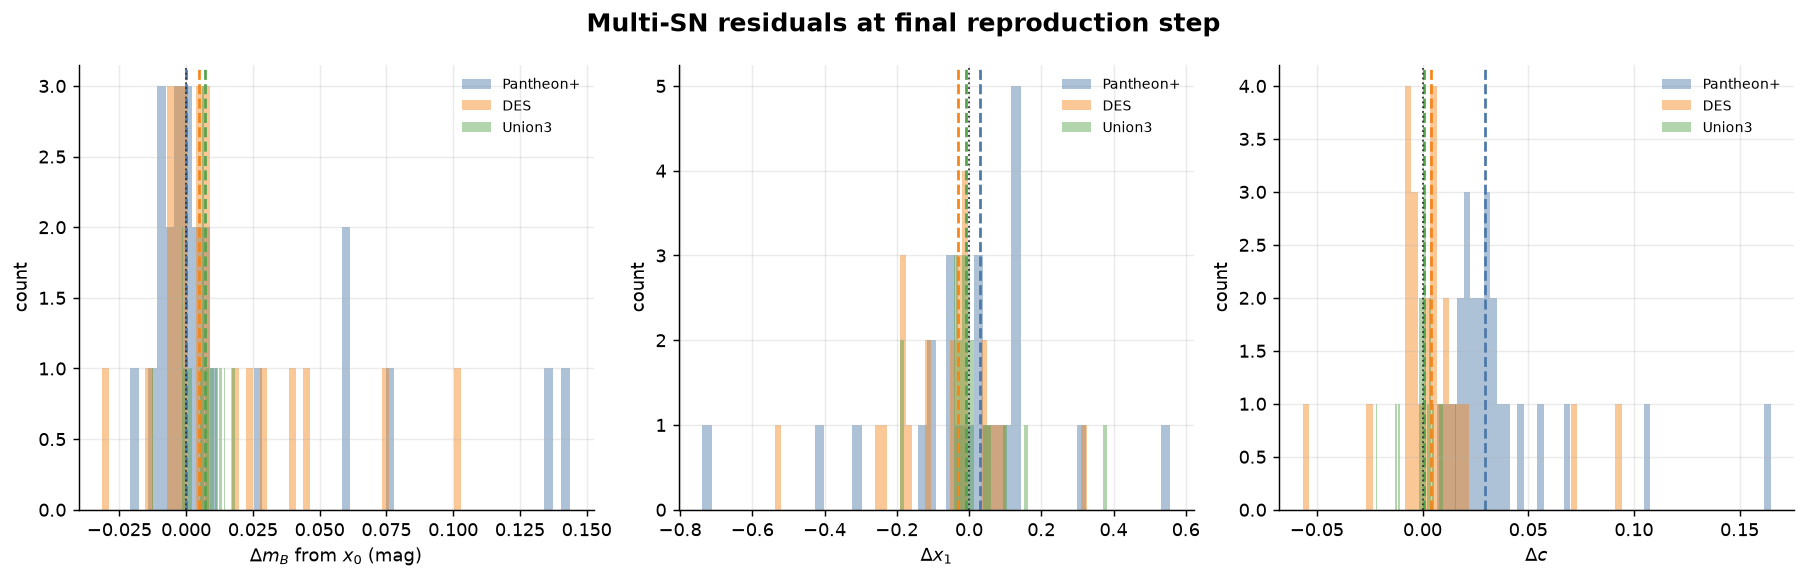

In [16]:
final_step = STEPS[-1]["name"]

# Uncomment to run on the first 20 matches:
# multi = run_all_matches(max_sne=20)

if "multi" in dir() and multi is not None and len(multi):
    print(f"Multi-SN summary: {len(multi)} rows across {multi['cid'].nunique()} SNe")
    print()
    print("Residuals at final step ({}):".format(final_step))
    display(multi.groupby("dataset")[["dmB_from_x0", "dx1", "dc"]].describe().round(4))

    colors = {"Pantheon+": "#4C78A8", "DES": "#F58518", "Union3": "#54A24B"}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, col, xlabel, bins in zip(
        axes,
        ["dmB_from_x0", "dx1", "dc"],
        [r"$\Delta m_B$ from $x_0$ (mag)", r"$\Delta x_1$", r"$\Delta c$"],
        [50, 50, 50],
    ):
        for dataset, grp in multi.groupby("dataset", sort=False):
            vals = grp[col].dropna().values
            ax.hist(vals, bins=bins, alpha=0.45, label=dataset,
                    color=colors[dataset], )
            ax.axvline(np.median(vals), color=colors[dataset], ls="--", lw=1.5)
        ax.axvline(0, color="0.2", lw=1, ls=":")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("count")
        ax.legend(frameon=False, fontsize=8)
    fig.suptitle("Multi-SN residuals at final reproduction step", fontsize=14, weight="bold")
    fig.tight_layout()
    fig.savefig(FIGDIR / "multi_sn_residuals_hist.png", bbox_inches="tight")
    plt.show()
else:
    print("Multi-SN data not available. Run `multi = run_all_matches(max_sne=20)` above first.")

In [17]:
multi.head()

,cid,des_cid,u3_uid,z,dataset,dmB_from_x0,dx1,dc,chisq_ndof,nfit
0,ASASSN-15pm,ASASSN-15pm,ASASSN-15pm,0.048370,Pantheon+,-0.020848,-0.411446,0.025446,3.830098,14
1,ASASSN-15pm,ASASSN-15pm,ASASSN-15pm,0.048370,DES,0.000251,-0.537387,0.021000,3.717007,29
2,1329312,1329312,01329312,0.344825,Pantheon+,0.000070,-0.062334,0.026611,2.341593,45
3,1329312,1329312,01329312,0.344825,DES,0.028736,0.094585,0.012665,1.006685,50
4,1329312,1329312,01329312,0.344825,Union3,0.006383,0.059811,0.000724,0.306511,43
